# Deep Learning (AI5100): Assignment-4
* Topic:AE and VAE

## 1. Autoencoders:
In this task, consider the MNIST dataset for training autoencoder models (with
a suitable regularization) with hidden (latent) dimension of 32, and 64.
* (a) Report the train and test reconstruction errors for the three models (display about 10 reconstructions
from the train and test data each).
* (b) Perform the reconstruction on the line joining two training data samples in the hidden space.
Consider at least 5 pairs of samples.

In [ ]:
# Imports Libraries
import torch
import random
import numpy as np
import matplotlib.pylab as plt
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from tqdm.notebook import tqdm, trange
import tarfile, requests, os
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# @title ##### Download MNIST Dataset { display-mode: "form" }

# Function for random seed
def set_seed(seed=None, seed_torch=True):
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

#DataLoader for workers
def seed_worker(worker_id):
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

SEED = 2024
set_seed(seed=SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

fname = 'MNIST.tar.gz'
name = 'mnist'
url = 'https://osf.io/y2fj6/download'

if not os.path.exists(name):
  print('\nDownloading MNIST dataset...')
  r = requests.get(url, allow_redirects=True)
  with open(fname, 'wb') as fh:
    fh.write(r.content)
  print('\nDownloading MNIST completed!\n')

if not os.path.exists(name):
  with tarfile.open(fname) as tar:
    tar.extractall(name)
    os.remove(fname)
else:
  print('MNIST dataset has been downloaded.\n')

# MNIST
mnist = datasets.MNIST('./mnist/',
                       train=True,
                       transform=transforms.ToTensor(),
                       download=False)
mnist_val = datasets.MNIST('./mnist/',
                           train=False,
                           transform=transforms.ToTensor(),
                           download=False)

train_set = mnist
dataset_name = 'MNIST'
data_shape = (1,28,28)
data_size = 28*28
test_set = mnist_val

### Autoencoder

In [ ]:
# Defined class
class AutoEncoder(nn.Module):

  def __init__(self, x_dim, h_dim):
    super().__init__()
    # Encoder layer
    self.enc_lin = nn.Linear(x_dim, h_dim)
    # Decoder layer
    self.dec_lin = nn.Linear(h_dim, x_dim)

  def encode(self, x):
    h = self.enc_lin(x)
    return h

  def decode(self, h):
    x_prime = self.dec_lin(h)
    return x_prime

  def forward(self, x):

    flat_x = x.view(x.size(0), -1)
    h = self.encode(flat_x)
    return self.decode(h).view(x.size())

In [ ]:
# Training Autoencoder
def train_autoencoder(autoencoder, dataset, device, epochs=20, batch_size=250,seed=0):
  autoencoder.to(device)
  optim = torch.optim.Adam(autoencoder.parameters(),
                           lr=1e-3,
                           weight_decay=1e-5)
  loss_fn = nn.MSELoss()
  g_seed = torch.Generator()
  g_seed.manual_seed(seed)
  loader = DataLoader(dataset,
                      batch_size=batch_size,
                      shuffle=True,
                      pin_memory=True,
                      num_workers=2,
                      worker_init_fn=seed_worker,
                      generator=g_seed)

  mse_loss = torch.zeros(epochs * len(dataset) // batch_size, device=device)
  i = 0
  # Iteration over epochs
  for epoch in trange(epochs, desc='Epoch'):
    for im_batch, _ in loader:
      im_batch = im_batch.to(device)
      optim.zero_grad()
      reconstruction = autoencoder(im_batch)
      # Loss calculation
      loss = loss_fn(reconstruction.view(batch_size, -1),
                     target=im_batch.view(batch_size, -1))
      loss.backward()
      optim.step()

      mse_loss[i] = loss.detach()
      i += 1
  autoencoder.to('cpu')
  return mse_loss.cpu()

In [ ]:
# Function to plot image
def plot_torch_image(image, ax=None):
  ax = ax if ax is not None else plt.gca()
  c, h, w = image.size()
  if c==1:
    cm = 'gray'
  else:
    cm = None

  # Torch images have shape (channels, height, width)
  im_plt = torch.clip(image.detach().cpu().permute(1,2,0).squeeze(), 0.0, 1.0)
  ax.imshow(im_plt, cmap=cm)
  ax.set_xticks([])
  ax.set_yticks([])
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)

#Plot Autoencoder data
def plot_data(ae):
  n_plot = 10
  plt.figure(figsize=(10, 4))
  for i in range(n_plot):

    idx = torch.randint(len(train_set), size=())
    image, _ = train_set[idx]
    # Reconstructed image from autoencoder
    with torch.no_grad():
      reconstruction = ae(image.unsqueeze(0)).reshape(image.size())

    #Plot MNIST Training Data
    plt.subplot(4, n_plot, i + 1)
    plot_torch_image(image)
    if i == 0:
      plt.ylabel('Train Data\nMNIST')

    #Plot Reconstruction Training Data
    plt.subplot(4, n_plot, i + 1 + n_plot)
    plot_torch_image(reconstruction)
    if i == 0:
      plt.ylabel(f'AE\n(Z={K})')

    idx = torch.randint(len(test_set), size=())
    image, _ = test_set[idx]
    #Reconstructed image from autoencoder
    with torch.no_grad():
      reconstruction = ae(image.unsqueeze(0)).reshape(image.size())

    #Plot MNIST Test Data
    plt.subplot(4, n_plot, i + 1 + 2*n_plot)
    plot_torch_image(image)
    if i == 0:
      plt.ylabel('Test Data\nMNIST')
    #Plot Reconstruction Test Data
    plt.subplot(4, n_plot, i + 1 + 3*n_plot)
    plot_torch_image(reconstruction)
    if i == 0:
      plt.ylabel(f'AE\n(Z={K})')

  plt.show()

Dimension K=10

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

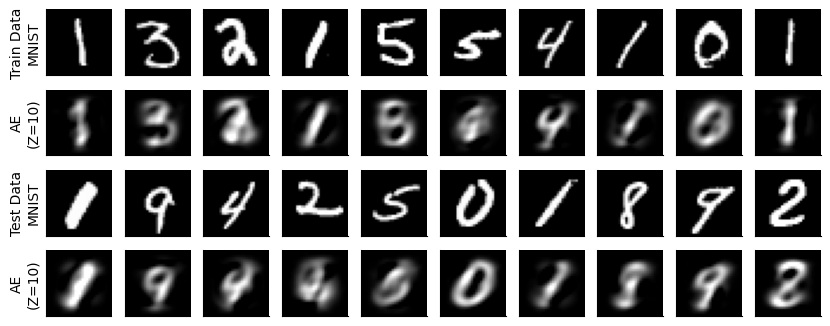

In [ ]:
#Hidden layer size
K = 10
set_seed(seed=SEED)
# Autoencoder
ae = AutoEncoder(data_size, K)
loss_k32 = train_autoencoder(ae, train_set, device=DEVICE, seed=SEED)
# Plot Loss
plot_data(ae)

Dimension K=32

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

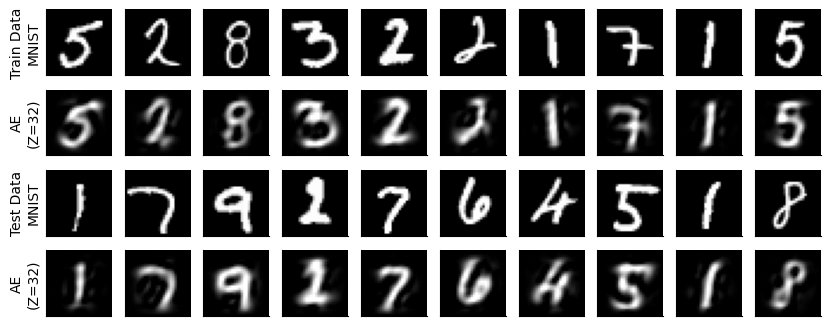

In [ ]:
#Hidden layer size
K = 32
set_seed(seed=SEED)
# Autoencoder
ae = AutoEncoder(data_size, K)
loss_k32 = train_autoencoder(ae, train_set, device=DEVICE, seed=SEED)
# Plot Loss
plot_data(ae)

Dimension D=64

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

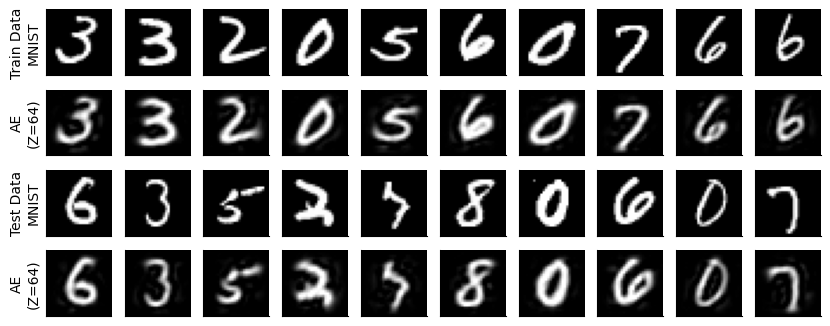

In [ ]:
# Hidden layer size
K = 64
set_seed(seed=SEED)
#Autoencoder
ae_k64 = AutoEncoder(data_size, K)
loss_k64 = train_autoencoder(ae_k64, train_set, device=DEVICE, seed=SEED)
#Plot Loss
plot_data(ae_k64)

### Comparing MSE Loss

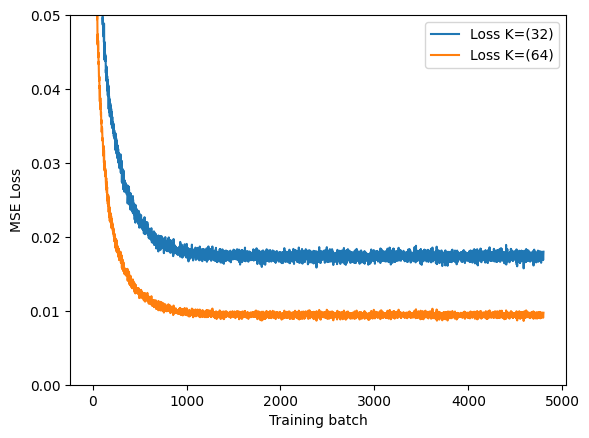

In [ ]:
#MSE loss across hidden layers of different size
plt.figure()
plt.plot(loss_k32,label='Loss K=(32)')
plt.plot(loss_k64,label='Loss K=(64)')
plt.ylim([0, 0.05])
plt.xlabel('Training batch')
plt.ylabel('MSE Loss')
plt.legend()
plt.axis('on')
plt.show()

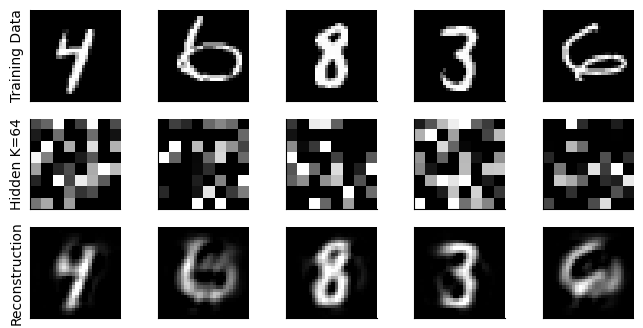

In [ ]:
n_plot = 5
plt.figure(figsize=(8, 4))
for i in range(n_plot):
  idx = torch.randint(len(train_set), size=())
  image, _ = train_set[idx]

  flat_img = image.view(image.size(0), -1)
  with torch.no_grad():
    recons = ae_k64.encode(flat_img)
  recons = recons.reshape(([1,8,8]))

  with torch.no_grad():
    reconstruction = ae(image.unsqueeze(0)).reshape(image.size())

  plt.subplot(3, n_plot, i + 1)
  plot_torch_image(image)
  if i == 0:
    plt.ylabel('Training Data')

  plt.subplot(3, n_plot, i + 1 + n_plot)
  plot_torch_image(recons)
  if i == 0:
    plt.ylabel('Hidden K=64')

  plt.subplot(3, n_plot, i + 1 + 2*n_plot)
  plot_torch_image(reconstruction)
  if i == 0:
    plt.ylabel('Reconstruction')


plt.show()

## 2. Variational Autoencoder (VAE):

Train a VAE (on MNIST dataset) for the tasks of generating
MNIST-like digits. Encoder learns a distribution in 16D space. After successfully training the VAE, generate 64 images and display.

In [ ]:
# Function for KL Divergence
def kl_q_p(zs, phi):
  b, n, k = zs.size()
  mu_q, log_sig_q = phi[:,:-1], phi[:,-1]
  log_p = -0.5*(zs**2)
  log_q = -0.5*(zs - mu_q.view(b,1,k))**2 / log_sig_q.exp().view(b,1,1)**2 - log_sig_q.view(b,1,-1)
  return (log_q - log_p).sum(dim=2).mean(dim=(0,1))

# Log of probability density function
def log_p_x(x, mu_xs, sig_x):

  b, n = mu_xs.size()[:2]
  x = x.reshape(b, 1, -1)
  _, _, p = x.size()
  squared_error = (x - mu_xs.view(b, n, -1))**2 / (2*sig_x**2)
  # Size of squared_error is [b,n,p]. log prob is by definition sum over [p].
  return -(squared_error + torch.log(sig_x)).sum(dim=2).mean(dim=(0,1))

class BiasLayer(nn.Module):
  def __init__(self, shape):
    super(BiasLayer, self).__init__()
    init_bias = torch.zeros(shape)
    self.bias = nn.Parameter(init_bias, requires_grad=True)

  def forward(self, x):
    return x + self.bias

# Variational Autoencoder Class
class VAE(nn.Module):

  def __init__(self, K, num_filters=32, filter_size=5):
    super(VAE, self).__init__()
    filter_reduction = 2 * (filter_size // 2)
    self.shape_after_conv = (num_filters,
                              data_shape[1]-2*filter_reduction,
                              data_shape[2]-2*filter_reduction)
    flat_size_after_conv = self.shape_after_conv[0] \
        * self.shape_after_conv[1] \
        * self.shape_after_conv[2]

    # Recognition model (encoder or q) part
    self.q_bias = BiasLayer(data_shape)
    self.q_conv_1 = nn.Conv2d(data_shape[0], num_filters, 5)
    self.q_conv_2 = nn.Conv2d(num_filters, num_filters, 5)
    self.q_flatten = nn.Flatten()
    self.q_fc_phi = nn.Linear(flat_size_after_conv, K+1)

    # Generative model (decoder or p) part
    self.p_fc_upsample = nn.Linear(K, flat_size_after_conv)
    self.p_unflatten = nn.Unflatten(-1, self.shape_after_conv)
    self.p_deconv_1 = nn.ConvTranspose2d(num_filters, num_filters, 5)
    self.p_deconv_2 = nn.ConvTranspose2d(num_filters, data_shape[0], 5)
    self.p_bias = BiasLayer(data_shape)

    # Extra parameter to learn scalar sig_x for all pixels
    self.log_sig_x = nn.Parameter(torch.zeros(()))

  def infer(self, x):
    s = self.q_bias(x)
    s = F.relu(self.q_conv_1(s))
    s = F.relu(self.q_conv_2(s))
    flat_s = s.view(s.size()[0], -1)
    phi = self.q_fc_phi(flat_s)
    return phi

  def generate(self, zs):
    b, n, k = zs.size()
    s = zs.view(b*n, -1)
    s = F.relu(self.p_fc_upsample(s)).view((b*n,) + self.shape_after_conv)
    s = F.relu(self.p_deconv_1(s))
    s = self.p_deconv_2(s)
    s = self.p_bias(s)
    mu_xs = s.view(b, n, -1)
    return mu_xs

  #Decoder
  def decode(self, zs):
    return self.generate(zs.unsqueeze(0))

  def forward(self, x):
    # Forward pass
    phi = self.infer(x)
    zs = rsample(phi, 1)
    return self.generate(zs).view(x.size())

  #ELBO return diff between true and estimated KL divergence
  def elbo(self, x, n=1):
    phi = self.infer(x)
    zs = rsample(phi, n)
    mu_xs = self.generate(zs)
    return log_p_x(x, mu_xs, self.log_sig_x.exp()) - kl_q_p(zs, phi)

#  Expected sample entropy
def expected_z(phi):
  return phi[:, :-1]


def rsample(phi, n_samples):
  b, kplus1 = phi.size()
  k = kplus1-1
  mu, sig = phi[:, :-1], phi[:,-1].exp()
  eps = torch.randn(b, n_samples, k, device=phi.device)
  return eps*sig.view(b,1,1) + mu.view(b,1,k)

# Train VAE
def train_vae(vae, dataset, epochs=10, n_samples=1000):
  opt = torch.optim.Adam(vae.parameters(), lr=1e-3, weight_decay=0)
  elbo_vals = []
  vae.to(DEVICE)
  vae.train()
  loader = DataLoader(dataset, batch_size=250, shuffle=True, pin_memory=True)
  for epoch in trange(epochs, desc='Epochs'):
    for im, _ in tqdm(loader, total=len(dataset) // 250, desc='Batches', leave=False):
      im = im.to(DEVICE)
      opt.zero_grad()
      loss = -vae.elbo(im)
      loss.backward()
      opt.step()
      #Update and store ELBO values
      elbo_vals.append(-loss.item())
  vae.to('cpu')
  vae.eval()
  return elbo_vals

#Function to generate images
def generate_images(autoencoder, K, n_images=1):
  output_shape = (n_images,) + data_shape
  with torch.no_grad():
    z = torch.randn(n_images,K)
    x = autoencoder.decode(z)
    return x.reshape(output_shape)

#Function to plot images
def plot_images(images, h=6, w=6, plt_title=''):
  plt.figure(figsize=(h*2, w*2))
  for i in range(h*w):
    plt.subplot(h, w, i + 1)
    plot_torch_image(images[i])
  plt.axis('off')
  plt.show()

Sample images

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

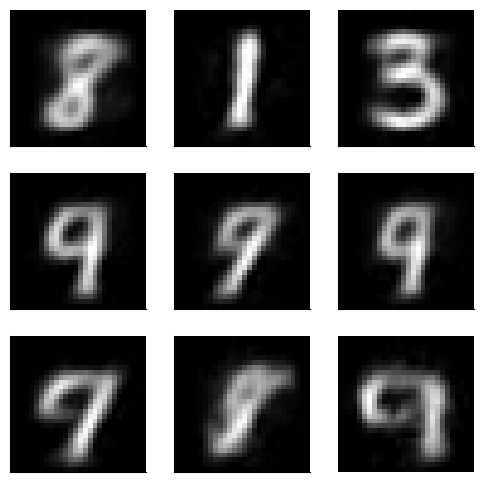

In [ ]:
## VAE output
K_VAE = 2
trained_VAE = VAE(K=K_VAE)
elbo_vals = train_vae(trained_VAE, train_set, n_samples=10000)
images = generate_images(trained_VAE, K_VAE, n_images=9)
plot_images(images, h=3,w=3)

VAE Output

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

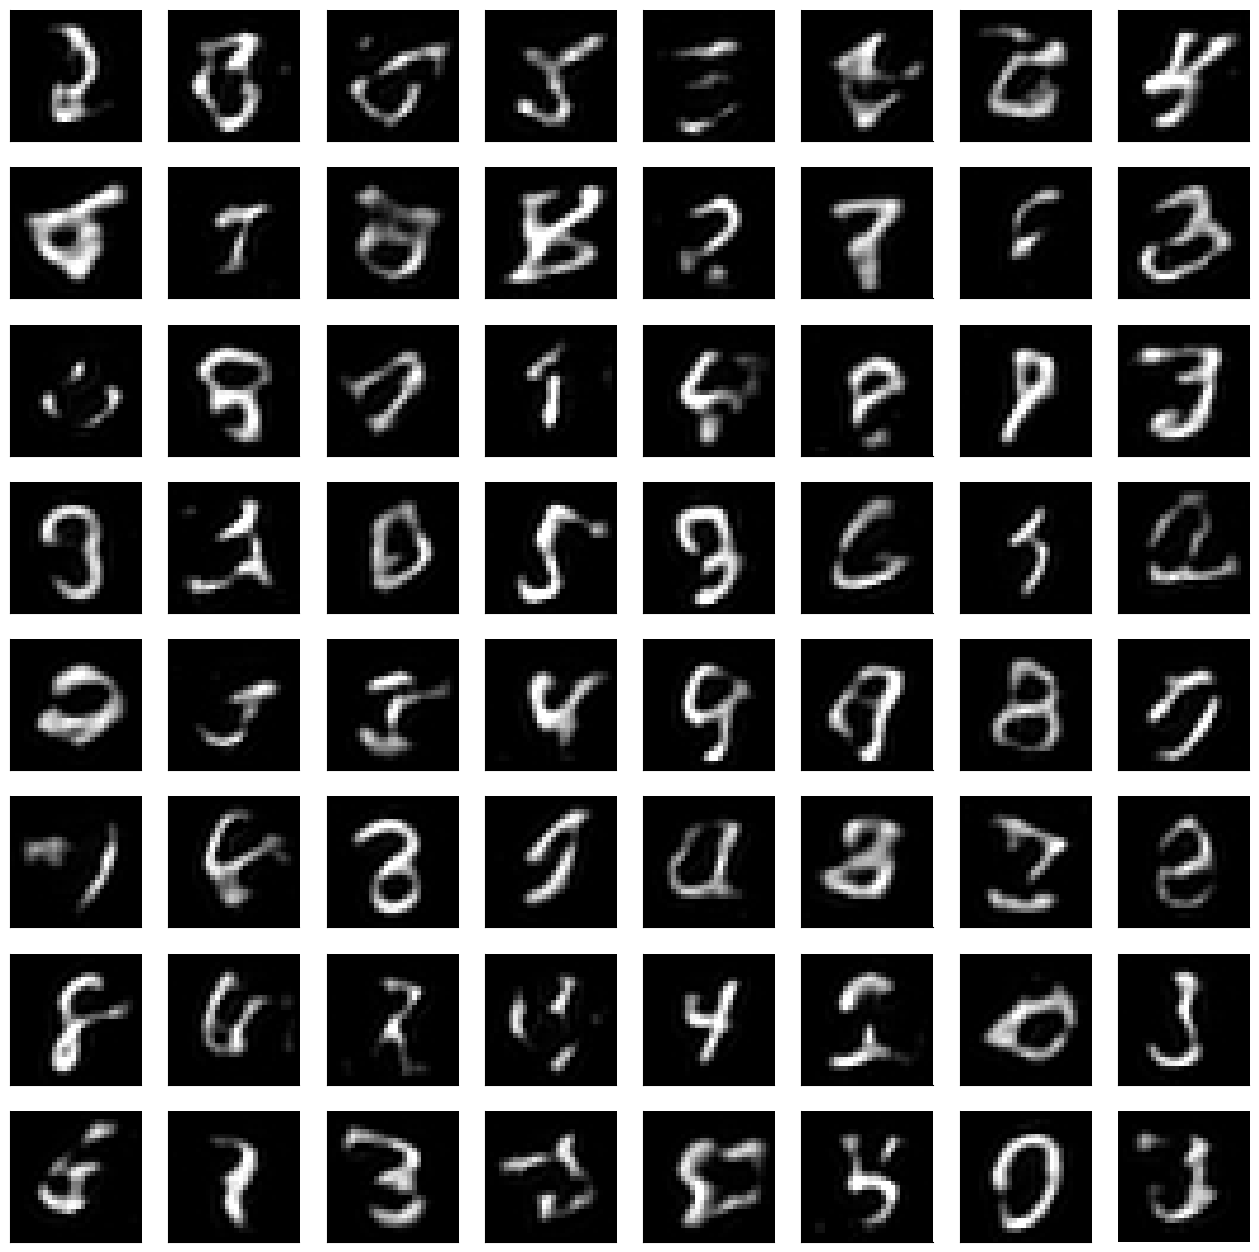

In [ ]:
K_VAE = 16
trained_VAE = VAE(K=K_VAE)
elbo_vals = train_vae(trained_VAE, train_set, n_samples=10000)

set_seed(seed=SEED)
## VAE output
images = generate_images(trained_VAE, K_VAE, n_images=64)
plot_images(images,h=8,w=8)